<div style="background: linear-gradient(135deg, rgb(108, 233, 36) 0%, rgb(174, 202, 16) 30%, rgb(255, 255, 255) 60%);
            padding: 10px; border-radius: 8px; margin: 10px 0; color: black; font-family: Arial, sans-serif; text-align: center; font-size: 24px;">

# **Многоцелевая модель для NER и классификации**
</div>

## **Краткое описани**

Я в роли NLP-инженера новостной аналитической платформы. Моя система одновременно извлекает сущности из новостных текстов (NER, токен-уровень) и определяет набор характеристик в документе (CLS, документ-уровень). Это позволяет автоматически помечать важные факты в новостях (персоны, организации, даты) и формировать теги и инцидентные фильтры для быстрого поиска и аналитики.

**Но есть проблема:** текущий пайплайн раздельно выполняет NER и классификацию событий. В результате признаки дублируются, а вычислительные ресурсы используются неэффективно. 

**Предположение** - совместное обучение (multi-task) повысит качество NER и/или стабильность классификации. Чтобы проверить гипотезу, я проьбую построить компактный воспроизводимый эксперимент, который:
- реализует объединённую encoder-модель, которая решает задачи NER и классификации событий;
- делает качественные и количественные выводы о взаимном влиянии задач.

## **Данные**

Используется публичный датасет NEREL, который можно найти по ссылке https://huggingface.co/datasets/danasone/nerel. Этот датасет содержит тексты, сущности и mutli-hot-векторы для классификации. Каждый такой вектор состоит из 30 бинарных значений: 0 —  эта характеристика не применима к тексту, 1 —  применима. Ниже список характеристик:
```html
['WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME',
'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 
'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 
'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 
'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 
'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS']
```



## **Цель проекта**
Реализовать **модель, которая может решать обе задачи лучше**, чем две раздельных — благодаря совместному обучению (Multi-Task Learning).


## **Содержание проекта**
1. БЛОК 0. Импорт библиотек и конфигурация модели
1. БЛОК 1. Загрузка датасета
1. БЛОК 2. ЕDA
1. БЛОК 3. Токенизация и выравнивание меток
1. БЛОК 4. Dataset и DataLoader
1. БЛОК 5. Модель (JointModel)
1. БЛОК 6. Тренировочный цикл
1. БЛОК 7. Финальный эксперимент на тестовый выборке
1. БЛОК 8. Инференс и анализ ошибок
1. БЛОК 9. Итоги работы

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, rgb(174, 202, 16) 30%, rgb(255, 255, 255) 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 0. Импорт библиотек и конфигурация модели</strong>
</div>

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from datasets import Dataset, concatenate_datasets
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorForTokenClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.metrics import f1_score

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import seaborn as sns

from collections import Counter

Фиксируем все источники случайности для полной воспроизводимости результатов, для избежания разных результатов метрик из-за случайной инициализации весов

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [4]:
# Назначаем нашу машину
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")

Используемое устройство: cuda


Для удобства проведения эксперементов сделаем пульт управления ноутбуком

In [5]:
# Задаем константы и гиперпараметры эксперимента
MODEL_NAME      = "surdan/LaBSE_ner_nerel" # выбрали модель дообученную непосредственно на NEREL
MAX_LEN         = 512    # максимальная длина в токенах
MAX_WORDS       = 350    # задаем длину текстов в словах
BATCH_SIZE      = 8      # размер мини-батча
NUM_EPOCHS      = 10     # максимальное число эпох
LR              = 2e-5   # learning rate для AdamW
DROPOUT         = 0.3    # дропаут
WARMUP_RATIO    = 0.1    # доля шагов с нарастающим LR
MAX_GRAD_NORM   = 1.0    # клиппинг нормы градиентов
USE_UNCERTAINTY = True   # автобаланс лоссов
GOALS_PATIENCE  = 2      # Количество эпох без улучшения, на случай если будет просто прыжок метрики

In [6]:
# Наши характеристики
CLS_LABELS = [
    'WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME',
    'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT', 
    'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF', 
    'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF', 
    'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF', 
    'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS'
]

NUM_CLS = len(CLS_LABELS)

В качестве настройки и задания констант мы закончили, перейдем непосредственно к загрузки датасета

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, #aeca10 30%, #ffffff 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 1. Загрузка датасета</strong>
</div>

В данном блоке мы будем загружать NEREL и разбивать на train/val/test. 

> [NEREL](https://huggingface.co/datasets/danasone/nerel) — это российский датасет для обработки естественного языка, предназначенный для решения задач извлечения именованных сущностей (Named Entity Recognition, NER) и извлечения отношений между ними (Relation Extraction). Он также используется для связывания сущностей с базами знаний (Entity Linking).

In [7]:
raw_ds = load_dataset("danasone/nerel")
full_data = raw_ds["train"]
print(f"Количество примеров: {len(full_data)} шт")

Количество примеров: 746 шт


Примеров честно говоря не так уж и много, но в дальнейшем, чтобы улучшить показатели метрик мы выполним аугментацию нашего train

In [8]:
# Непосредственно разбивка на train/val/test
train_idx, test_idx = train_test_split(
    range(len(full_data)), test_size=0.2, random_state=SEED
)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.25, random_state=SEED
)

train_data = full_data.select(train_idx)
val_data = full_data.select(val_idx)
test_data = full_data.select(test_idx)

print(f"\nРазмеры наших выборок:")
print(f"train: {len(train_data):,} шт")
print(f"val: {len(val_data):,} шт")
print(f"test: {len(test_data):,} шт")
print(f"\nПоля датасета: {full_data.column_names}")
print(f"\nПример записи:")
print(full_data[0])


Размеры наших выборок:
train: 447 шт
val: 149 шт
test: 150 шт

Поля датасета: ['tokens', 'token_spans', 'tags', 'cls_vec', 'text']

Пример записи:
{'tokens': ['Пулеметы,', 'автоматы', 'и', 'снайперские', 'винтовки', 'изъяты', 'в', 'арендуемом', 'американцами', 'доме', 'в', 'Бишкеке', '05/08/2008', '10:35', 'БИШКЕК,', '5', 'августа', '/Новости-Грузия/.', 'Правоохранительные', 'органы', 'Киргизии', 'обнаружили', 'в', 'доме,', 'арендуемом', 'гражданами', 'США', 'в', 'Бишкеке,', 'пулеметы,', 'автоматы', 'и', 'снайперские', 'винтовки,', 'сообщает', 'во', 'вторник', 'пресс-служба', 'МВД', 'Киргизии.', '"В', 'ходе', 'проведения', 'оперативно-профилактического', 'мероприятия', 'под', 'кодовым', 'названием', '"Арсенал"', 'в', 'новостройке', 'Ынтымак,', 'в', 'доме,', 'принадлежащем', '66-летнему', 'гражданину', 'Киргизии', 'и', 'арендуемом', 'гражданами', 'США,', 'обнаружены', 'и', 'изъяты:', 'шесть', 'крупнокалиберных', 'пулеметов', 'с', 'оптическим', 'прицелом', 'и', 'с', 'приборами', 'ночног

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, #aeca10 30%, #ffffff 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 2. ЕDA</strong>
</div>

В качестве первоначальной визуализации выведим первые 10 токенов их метки и характеристики документа

In [9]:
example = train_data[0]
print("Первые 10 токенов:", example["tokens"][:10])
print("NER-метки:", example["tags"][:10])

Первые 10 токенов: ['Виталий', 'Кличко', 'отомстил', 'Дереку', 'Чисоре', 'за', 'пощёчину', '40-летний', 'украинский', 'боксер']
NER-метки: ['B-PERSON', 'I-PERSON', 'O', 'B-PERSON', 'I-PERSON', 'O', 'O', 'B-AGE', 'B-NATIONALITY', 'B-PROFESSION']


In [10]:
event_vec = example["cls_vec"]
active = [CLS_LABELS[i] for i, v in enumerate(event_vec) if v == 1]
print("Характеристики:", active)

Характеристики: ['ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME', 'ORIGINS_FROM', 'AGENT', 'AGE_IS', 'PRODUCES', 'AWARDED_WITH', 'INANIMATE_INVOLVED', 'ABBREVIATION']


Так как у нас нейронка не умеет работать со строками а работает с числами, то переведем теги в числовые индексы

In [11]:
all_tags_flat = [tag for ex in full_data for tag in ex["tags"]]
tag_names = sorted(set(all_tags_flat))

id2tag = {i: t for i, t in enumerate(tag_names)}
tag2id = {t: i for i, t in id2tag.items()}
NUM_NER = len(tag_names)

print("Все NER-теги:", tag_names)
print(f"Уникальных меток: {NUM_NER}")

Все NER-теги: ['B-AGE', 'B-AWARD', 'B-CITY', 'B-COUNTRY', 'B-CRIME', 'B-DATE', 'B-DISEASE', 'B-DISTRICT', 'B-EVENT', 'B-FACILITY', 'B-FAMILY', 'B-IDEOLOGY', 'B-LANGUAGE', 'B-LAW', 'B-LOCATION', 'B-MONEY', 'B-NATIONALITY', 'B-NUMBER', 'B-ORDINAL', 'B-ORGANIZATION', 'B-PENALTY', 'B-PERCENT', 'B-PERSON', 'B-PRODUCT', 'B-PROFESSION', 'B-RELIGION', 'B-STATE_OR_PROVINCE', 'B-TIME', 'B-WORK_OF_ART', 'I-AGE', 'I-AWARD', 'I-CITY', 'I-COUNTRY', 'I-CRIME', 'I-DATE', 'I-DISEASE', 'I-DISTRICT', 'I-EVENT', 'I-FACILITY', 'I-FAMILY', 'I-IDEOLOGY', 'I-LAW', 'I-LOCATION', 'I-MONEY', 'I-NATIONALITY', 'I-NUMBER', 'I-ORDINAL', 'I-ORGANIZATION', 'I-PENALTY', 'I-PERCENT', 'I-PERSON', 'I-PRODUCT', 'I-PROFESSION', 'I-RELIGION', 'I-STATE_OR_PROVINCE', 'I-TIME', 'I-WORK_OF_ART', 'O']
Уникальных меток: 58


Собственно на эти 58 классов и будет обучаться наша голова модели.

Далее построим график распределения этих NER-тегов

In [12]:
# Распределение NER-тегов 
all_ner_tags = [tag for ex in train_data for tag in ex["tags"]]
tag_counts = Counter(all_ner_tags)
sorted_items = sorted(tag_counts.items(), key=lambda x: -x[1])
tags_sorted, cnts_sorted = zip(*sorted_items)

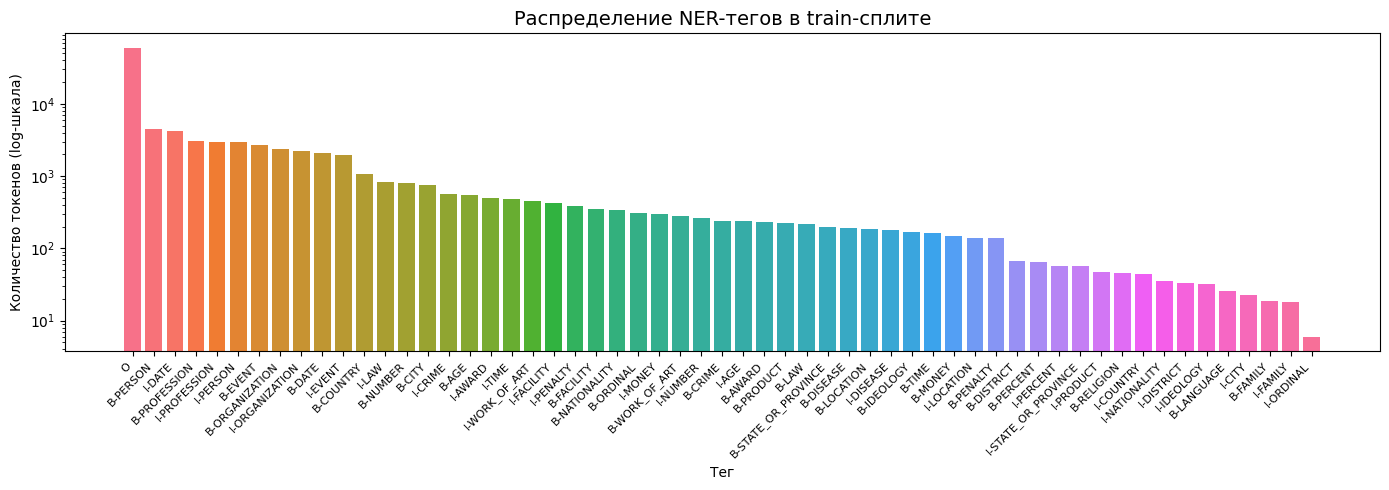

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(tags_sorted, cnts_sorted, color=sns.color_palette("husl", len(tags_sorted)))
ax.set_title("Распределение NER-тегов в train-сплите", fontsize=14)
ax.set_ylabel("Количество токенов (log-шкала)")
ax.set_xlabel("Тег")
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Ну что тут сказать, есть дисбаланс классов, чаще всего встречается тег 0 - не сущность, но это типично для большинства слов в текстах, они не всегда будут именованными сущностями. 

Можно разбить на три части теги:

1. **Частые** - начиная от B-PERSON заканчивая I-EVENT - модель будет распозновать этих ребят холрошо
1. **Средняя часть** - от B-COUNTRY до B-PENALTY - всё ещё будет усваиваться моделью, но качество чуть по ниже
1. **Редкие** - от B-DISTRICT и ниже - это будет основа наших ошибок и проблем, которые будут метрики тащить вниз. O-ORDINAL - там совсем туши свет.

Далее взглянем на баланс классов характеристик наших, которых 30 штук.
Посчитаем долю документов для каждой характеристики, где она активна, и где не активна.

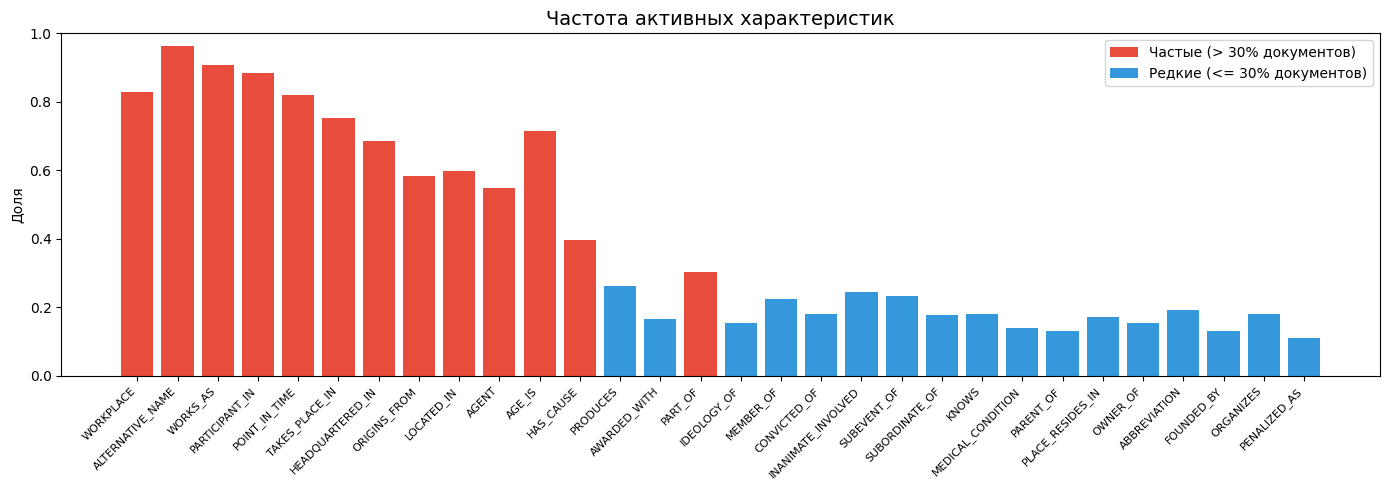

In [14]:
event_matrix = np.array([ex["cls_vec"] for ex in train_data])
cls_freq = event_matrix.mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
palette = ["#e74c3c" if f > 0.3 else "#3498db" for f in cls_freq]
ax.bar(CLS_LABELS, cls_freq, color=palette)
ax.set_title("Частота активных характеристик", fontsize=14)
ax.set_ylabel("Доля")
ax.set_ylim(0, 1)

legend_elements = [
    Patch(facecolor="#e74c3c", label="Частые (> 30% документов)"),
    Patch(facecolor="#3498db", label="Редкие (<= 30% документов)"),
]
ax.legend(handles=legend_elements, loc="upper right")

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Красные характеристики у нас являются самыми активными в документах, доля синих гораздо ниже. Что это значит? А значит вот что - модель будет лучше предсказывать частые классы и систематически занижать вероятность редких классов

Построим дополнительно графих длин текстов, чтобы понимать какую обрезку для модели выставлять MAX_LEN

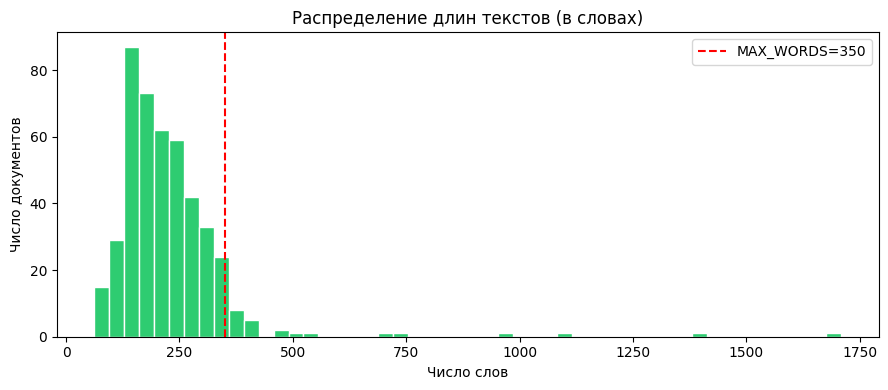

Медиана: 205 слов
Максимум: 1710 слов
Минимум: 62 слов
Доля > MAX_WORDS (350): 6.7%


In [ ]:
lengths = [len(ex["tokens"]) for ex in train_data]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=50, color="#2ecc71", edgecolor="white")
ax.axvline(MAX_WORDS, color="red", ls="--", label=f"MAX_WORDS={MAX_WORDS}")
ax.set_title("Распределение длин текстов (в словах)")
ax.set_xlabel("Число слов")
ax.set_ylabel("Число документов")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Медиана: {np.median(lengths):.0f} слов")
print(f"Максимум: {np.max(lengths):.0f} слов")
print(f"Минимум: {np.min(lengths):.0f} слов")
pct_long = np.mean(np.array(lengths) > MAX_WORDS) * 100
print(f"Доля > MAX_WORDS ({MAX_WORDS}): {pct_long:.1f}%")

Вообще, мне не очень нравятся во всём это деле тексты, где слов более 350, почему? Потому что они очень редкие и могут эти редкости нам снижать наши метрики. А там итак хватает причин с разностью классов. Предлагается лишить наш словарик несколько процентов текстов. И ограничить датасет на показатель MAX_WORDS.

Собственно говоря проведем дополнительный фильтр нашего сплита train/val/test 

In [16]:
train_data = train_data.filter(lambda ex: len(ex["tokens"]) <= MAX_WORDS,
                                desc="Фильтрация train")
val_data = val_data.filter(  lambda ex: len(ex["tokens"]) <= MAX_WORDS,
                                desc="Фильтрация val")
test_data = test_data.filter( lambda ex: len(ex["tokens"]) <= MAX_WORDS,
                                desc="Фильтрация test")

print(f"Обновленные выборки:")
print(f"train: {len(train_data)} примеров")
print(f"val: {len(val_data)} примеров")
print(f"test: {len(test_data)} примеров")


Обновленные выборки:
train: 417 примеров
val: 138 примеров
test: 141 примеров


Ну плюс минус баланс разделения сохранился. Теперь нам надо сделать аугментацию train-данных, а то предчувствую что ей будет мало на обучение примеров.

Для чего мы это делаем, а вот для чего:
- Увеличиваеv размер train-набора без сбора новых данных;
- Учим модель быть устойчивой к неполным контекстам;
- Компенсирует потерю текстов после фильтрации длинных примеров;

Token dropout: удаляем токены с малой вероятностью. Цепочки `B-/I-` удаляются только целиком- чтобы не нарушать BIO-разметку.

- BIO-разметка требует: после B-TYPE всегда идут I-TYPE той же сущности
- Если удалить только B-токен, следующий I- окажется сиротой


In [ ]:
def augment_example(tokens, tags, cls_vec, drop_prob=0.08):
    
    """Аугментация текста через token dropout

    Args:
        tokens (_type_): Список слов исходника
        tags (_type_): Метки
        cls_vec (_type_): Вектор характеристик
        drop_prob (float, optional): Вероятность удаления токена. Defaults to 0.08.

    Returns:
        _type_: Аугментированные токены, метки и вектор характеристик
    """
    
    new_tokens, new_tags = [], []
    i = 0
    while i < len(tokens):
        tag = tags[i]
        if tag.startswith("B-"):
            # Собираем всю цепочку сущности: B-TYPE + все следующие I-TYPE
            chain_tok, chain_tag = [tokens[i]], [tags[i]]
            j = i + 1
            while j < len(tokens) and tags[j].startswith("I-"):
                chain_tok.append(tokens[j])
                chain_tag.append(tags[j])
                j += 1
            # Цепочку удаляем в 4 раза реже O-токенов 
            if random.random() > drop_prob / 4:
                new_tokens.extend(chain_tok)
                new_tags.extend(chain_tag)
            i = j
        else:
            # O-токены удаляем с вероятностью drop_prob
            if random.random() > drop_prob:
                new_tokens.append(tokens[i])
                new_tags.append(tags[i])
            i += 1

    # Защита от пустого результата - возвращаем оригинал
    if len(new_tokens) == 0:
        return tokens, tags, cls_vec
    return new_tokens, new_tags, cls_vec

Далее создаем 3 аугментированные копии каждого примера для компенсации потери длинных текстов и разнообразить варианты текстов для модели

In [18]:
augmented_examples = []
for ex in train_data:
    for _ in range(3):
        new_tok, new_tag, new_cls = augment_example(
            ex["tokens"], ex["tags"], ex["cls_vec"], drop_prob=0.08
        )
        augmented_examples.append({
            "tokens": new_tok,
            "tags" : new_tag,
            "cls_vec" : new_cls,
            "token_spans" : [[0, 0]] * len(new_tok),
            "text": " ".join(new_tok),
        })

# Создаём Dataset из аугментированных примеров с той же схемой полей
aug_ds = Dataset.from_list(augmented_examples, features=train_data.features)
train_data_aug = concatenate_datasets([train_data, aug_ds])

print(f"Оригинальный train: {len(train_data):,}")
print(f"Аугментированный: {len(aug_ds):,}")
print(f"Итого для обучения: {len(train_data_aug):,}")

Оригинальный train: 417
Аугментированный: 1,251
Итого для обучения: 1,668


Ну вот картина с объемом данных вроде стала получше. Теперь перейдем к следующим этапам

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, #aeca10 30%, #ffffff 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 3. Токенизация и выравнивание меток</strong>
</div>

In [19]:
# Инициализация токенизатора
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
print(f"Токенизатор загружен: {MODEL_NAME}")
print(f"Размер словаря: {tokenizer.vocab_size}")


Токенизатор загружен: surdan/LaBSE_ner_nerel
Размер словаря: 55083


Токенизатор наш загружен, теперь надо выравнить NER-метки.

Стратегия выравнивания:
- Первый токен слова -  получает метку слова (B-ORGANIZATION)
- Последующие токены (##нефть) - получают -100
- Спецтокены [CLS], [SEP] - получают -100
- Значение -100 игнорируется CrossEntropyLoss - который мы реализуем в функции

In [ ]:
def tokenize_and_align_labels(examples, max_length=MAX_LEN):
    
    """Токенизирует батч текстов и выравнивает метки NER по токенам

    Args:
        examples (_type_): Батч примеров с полями "tokens", "tags" и "cls_vec"
        max_length (_type_, optional): Максимальная длина токенов. Defaults to MAX_LEN.

    Returns:
        _type_: Токенизированный батч
    """
    
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True, # сообщаем что вход уже разбит на слова
        truncation=True,
        max_length=max_length,
    )

    all_labels = []
    for i, word_labels in enumerate(examples["tags"]):
        word_ids = tokenized.word_ids(batch_index=i) # индекс слова для каждого токена
        aligned = []
        prev_word_id = None
        for wid in word_ids:
            if wid is None:
                aligned.append(-100)                     # [CLS], [SEP] - игнорируем
            elif wid != prev_word_id:
                aligned.append(tag2id[word_labels[wid]]) # первый токен слова - берём метку
            else:
                aligned.append(-100)                     # ##-продолжения - игнорируем
            prev_word_id = wid
        all_labels.append(aligned)

    tokenized["labels"] = all_labels # NER-метки (числа или -100)
    tokenized["event_labels"] = examples["cls_vec"]
    return tokenized

In [21]:
sample = tokenize_and_align_labels(
    {"tokens": [train_data[0]["tokens"]],
     "tags": [train_data[0]["tags"]],
     "cls_vec": [train_data[0]["cls_vec"]]}
)
print("Токены:", tokenizer.convert_ids_to_tokens(sample["input_ids"][0][:15]))
print("Метки:", sample["labels"][0][:15])

Токены: ['[CLS]', 'Виталий', 'Кличко', 'ото', '##мс', '##тил', 'Де', '##рек', '##у', 'Чи', '##сор', '##е', 'за', 'по', '##щ']
Метки: [-100, 22, 50, 57, -100, -100, 22, -100, -100, 50, -100, -100, 57, 57, -100]


Вроде уют, двигаемся дальше и выполним токенизацию всех сплитов

In [22]:
cols_to_remove = full_data.column_names  

# Обучаем на аугментированном train
train_tok = train_data_aug.map(
    tokenize_and_align_labels, batched=True,
    remove_columns = train_data_aug.column_names,
    desc="Токенизация train+aug"
)

# Val и test токенизируем без аугментации
val_tok = val_data.map(
    tokenize_and_align_labels, batched=True,
    remove_columns=cols_to_remove,
    desc="Токенизация val"
)

test_tok = test_data.map(
    tokenize_and_align_labels, batched=True,
    remove_columns=cols_to_remove,
    desc="Токенизация test"
)

print("Поля после токенизации:", train_tok.column_names)

Поля после токенизации: ['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'event_labels']


<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, #aeca10 30%, #ffffff 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 4. Dataset и DataLoader</strong>
</div>

Мы будем оборачивать токенизированный HuggingFace Dataset в стандартный PyTorch Dataset, конвертируя все данные в тензоры при инициализации.

Почему не используем HF Dataset напрямую в DataLoader, потому что:
HuggingFace Dataset имеет собственный метод __getitems__, который принимает список индексов и возвращает батч-словарь. PyTorch DataLoader обнаруживает этот метод и вызывает его со списком вместо одного int - это вызывает TypeError в нашем __getitem__, который ожидает целое число.

In [ ]:
class NERCLSDataset(Dataset):
    
    """ Обертка над HF Dataset для удобства работы с PyTorch DataLoader

    Args:
        Dataset (_type_): Наш Dataset для задачи NER
    """    
    
    def __init__(self, hf_dataset):
        
        """Конвектируем в список пайтон словарей с готовыми тензорами для обучения

        Args:
            hf_dataset (_type_): токенизированный датасет от Hugging Face
        """  
              
        self._items = []
        for i in range(len(hf_dataset)):
            item = hf_dataset[i]
            self._items.append({
                "input_ids" : torch.tensor(item["input_ids"],dtype=torch.long),
                "attention_mask": torch.tensor(item["attention_mask"], dtype=torch.long),
                "labels" : torch.tensor(item["labels"], dtype=torch.long),
                "event_labels" : torch.tensor(item["event_labels"],dtype=torch.float),
            })

    def __len__(self):
        return len(self._items)

    def __getitem__(self, idx):
        return self._items[idx]

    # Явно отключаем батчевый метод HF
    __getitems__ = None


train_ds = NERCLSDataset(train_tok)
val_ds = NERCLSDataset(val_tok)
test_ds = NERCLSDataset(test_tok)
print(f"train: {len(train_ds)}; val: {len(val_ds)}; test: {len(test_ds)}.")

train: 1668; val: 138; test: 141.


Что у нас дальше выходит, каждый текст после токенизации имеет разную длину - один 50 токенов, другой 200, третий 380.
Нам надо сделать одинаковую форму и дополнить до нужной длины самого длинного в батче.

In [24]:
data_collator = DataCollatorForTokenClassification(
    tokenizer= tokenizer,
    padding=True,             # паддинг до длины самого длинного в батче
    label_pad_token_id=-100,  # заполняем labels значением -100
    return_tensors="pt",
)

In [ ]:
def collate_fn(batch):
    
    """Объеденяем список примеров в батч

    Args:
        batch (_type_): батч

    Returns:
        _type_: NER батч с паддингом 
    """    
    
    # DataCollator паддит NER-поля (разная длина у разных примеров)
    ner_batch = data_collator([
        {
            "input_ids" : b["input_ids"].tolist(),
            "attention_mask": b["attention_mask"].tolist(),
            "labels" : b["labels"].tolist(),
        }
        for b in batch
    ])
    # event_labels — всегда вектор длиной 30, паддинг не нужен
    ner_batch["event_labels"] = torch.stack([b["event_labels"] for b in batch])
    return ner_batch

In [26]:
# DataLoader с нашим collate_f
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds,batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# проверяем форму батча перед запуском обучения
batch = next(iter(train_loader))
print("\nФорма батча:")
for k, v in batch.items():
    print(f"  {k}: {v.shape}")


Форма батча:
  input_ids: torch.Size([8, 434])
  attention_mask: torch.Size([8, 434])
  labels: torch.Size([8, 434])
  event_labels: torch.Size([8, 30])


<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, #aeca10 30%, #ffffff 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 5. Модель (JointModel)</strong>
</div>

Собираем многозадачную модель для решения задач по NER и CLS классификации.

In [ ]:
class JointModel(nn.Module):
    
    """
    Наша многозадачная модель для NER и классификации характеристик.
    """

    def __init__(
        self,
        model_name: str,
        num_ner_labels: int,
        num_cls_labels: int,
        dropout_prob: float = 0.1,
        use_uncertainty_weight: bool = True,
    ):
        
        """ИНИТ

        Args:
            model_name (str): Предобученная модлель из HF
            num_ner_labels (int): Число меток NER
            num_cls_labels (int): Число характеристик для классификации
            dropout_prob (float, optional): Вероятность dropout. Defaults to 0.1.
            use_uncertainty_weight (bool, optional): Использовать веса неопределенности. Defaults to True.
        """        
        
        super().__init__()
        self.use_uncertainty_weight = use_uncertainty_weight
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size 
        self.dropout = nn.Dropout(dropout_prob)
        self.token_classifier = nn.Linear(hidden_size, num_ner_labels)
        self.cls_classifier = nn.Linear(hidden_size, num_cls_labels)
        self.log_sigma_token = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_cls = nn.Parameter(torch.tensor(0.0))
        self.token_loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        self.register_buffer(
            "cls_pos_weight",
            torch.ones(num_cls_labels) * 2.0  # штраф за пропуск положительного класса x2
        )


    def forward(self, input_ids, attention_mask, labels=None, event_labels=None):
        
        """Прямой проход модели: кодируем, предсказываем NER и характеристики, вычисляем лосс

        Args:
            input_ids (_type_): токены
            attention_mask (_type_): маска внимания
            labels (_type_, optional): метки NER. Defaults to None.
            event_labels (_type_, optional): метки характеристик. Defaults to None.

        Returns:
            _type_: словарь с результатами
        """       
         
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        sequence_out = self.dropout(outputs.last_hidden_state)  # (B, L, H)

        cls_out = sequence_out[:, 0, :]  # (B, H)

        token_logits = self.token_classifier(sequence_out)  # (B, L, NUM_NER)
        cls_logits = self.cls_classifier(cls_out)           # (B, NUM_CLS)

        # Вычисление лосса
        loss = None
        if labels is not None and event_labels is not None:
            C = token_logits.size(-1)

            # NER-лосс
            token_loss = self.token_loss_fct(
                token_logits.view(-1, C),  # (B*L, NUM_NER) - разворачиваем батч
                labels.view(-1)            # (B*L,) - плоский список меток
            )

            # CLS-лосс
            cls_loss_fct = nn.BCEWithLogitsLoss(pos_weight=self.cls_pos_weight)
            cls_loss = cls_loss_fct(cls_logits, event_labels)

            if self.use_uncertainty_weight:
                loss = (
                    torch.exp(-2.0 * self.log_sigma_token) * token_loss + self.log_sigma_token
                    + torch.exp(-2.0 * self.log_sigma_cls) * cls_loss + self.log_sigma_cls
                )
            else:
                # сумма без взвешивания
                loss = token_loss + cls_loss

        return {"loss": loss, "token_logits": token_logits, "cls_logits": cls_logits}

In [ ]:
# Инициализация модели
model = JointModel(
    model_name= MODEL_NAME,
    num_ner_labels = NUM_NER,
    num_cls_labels = NUM_CLS,
    dropout_prob = DROPOUT,
    use_uncertainty_weight = USE_UNCERTAINTY,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров : {total_params:,}")
print(f"Обучаемых : {trainable:,}")
print(f"pos_weight device: {model.cls_pos_weight.device}")

Some weights of BertModel were not initialized from the model checkpoint at surdan/LaBSE_ner_nerel and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Всего параметров : 128,412,762
Обучаемых : 128,412,762
pos_weight device: cuda:0


<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, #aeca10 30%, #ffffff 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 6. Тренировочный цикл</strong>
</div>

Переходим непостредственно к тренировочному циклу для вычисления метрик качества на наших данных.
Метрики:
- NER: token_f1 - усредняем по классам, каждый класс равнозначен
- CLS: cls_micro_f1 - суммируем TP/FP/FN по всем 30 классам вместе

In [29]:
def evaluate(model, loader, threshold=0.5):
    
    """Функция оценки модели на валидации или тесте: считает среднюю потерю, F1 для NER и F1 для CLS

    Args:
        model (_type_): Модель для оценки
        loader (_type_): Загрузчик данных (DataLoader) для валидации или теста
        threshold (float, optional): Порог для бинаризации предсказаний классификации. Defaults to 0.5.

    Returns:
        _type_: Кортеж из средней потери, F1-score для NER и F1-score для CLS
    """    
    
    model.eval()  # отключаем Dropout и BatchNorm в режиме инференса
    total_loss = 0.0
    n_batches = 0
    all_ner_preds, all_ner_trues = [], []
    all_cls_preds, all_cls_trues = [], []

    with torch.no_grad():  # отключаем граф автодифференцирования — экономим память
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(
                input_ids =batch["input_ids"],
                attention_mask = batch["attention_mask"],
                labels = batch["labels"],
                event_labels = batch["event_labels"],
            )
            total_loss += out["loss"].item()
            n_batches += 1

            # NER: собираем предсказания
            preds = out["token_logits"].argmax(dim=-1).cpu().numpy().flatten()
            trues = batch["labels"].cpu().numpy().flatten()
            mask = trues != -100                             # маска валидных позиций
            all_ner_preds.extend(preds[mask].tolist())
            all_ner_trues.extend(trues[mask].tolist())

            # CLS: сигмоид и порог для бинаризации
            probs = torch.sigmoid(out["cls_logits"]).cpu().numpy()
            all_cls_preds.append((probs > threshold).astype(int))
            all_cls_trues.append(batch["event_labels"].cpu().numpy().astype(int))

    # Глобальный подсчёт F1 по всем собранным примерам
    ner_f1 = f1_score(all_ner_trues, all_ner_preds, average="macro", zero_division=0)
    cls_f1 = f1_score(
        np.vstack(all_cls_trues),  # матрица истинных меток
        np.vstack(all_cls_preds),  # матрица предсказаний
        average = "micro", zero_division = 0
    )
    
    return total_loss / n_batches, ner_f1, cls_f1

In [30]:
# делаем оптимизатор и планировщик LR
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Всего шагов обучения : {total_steps}")
print(f"Шагов warmup : {warmup_steps}")
print(f"Шагов после warmup : {total_steps - warmup_steps}")


Всего шагов обучения : 2090
Шагов warmup : 209
Шагов после warmup : 1881


In [31]:
# Тренировочный цикл
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "token_f1": [],
    "cls_micro_f1": []
}

# Папка для сохранения модели
os.makedirs("model", exist_ok=True)
best_model_path = "model/best_joint_model.pt"

best_combined_score = -1.0
best_metrics = {}
goals_streak  = 0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss_accum = 0.0

    for step, batch in enumerate(train_loader, 1):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()

        out = model(
            input_ids =batch["input_ids"],
            attention_mask = batch["attention_mask"],
            labels =batch["labels"],
            event_labels = batch["event_labels"],
        )
        loss = out["loss"]
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()

        train_loss_accum += loss.item()
        if step % 50 == 0:
            print(f"  Epoch {epoch}, step {step}/{len(train_loader)},"
                  f" loss={loss.item():.4f}", end="\r")

    train_loss = train_loss_accum / len(train_loader)

    # Фаза валидации 
    val_loss, token_f1, cls_micro_f1 = evaluate(model, val_loader)

    uw_str = ""
    if USE_UNCERTAINTY:
        sigma_tok = torch.exp(model.log_sigma_token).item()
        sigma_cls = torch.exp(model.log_sigma_cls).item()
        uw_str = f" | sigma_tok={sigma_tok:.3f}, sigma_cls={sigma_cls:.3f}"

    print(f"\nEpoch {epoch}/{NUM_EPOCHS} "
          f"| train_loss={train_loss:.4f} "
          f"| val_loss={val_loss:.4f} "
          f"| token_f1={token_f1:.4f} "
          f"| cls_micro_f1={cls_micro_f1:.4f}"
          f"{uw_str}")

    # Сохранение модели
    combined_score = token_f1 + cls_micro_f1
    if combined_score > best_combined_score:
        best_combined_score = combined_score
        best_metrics = {
            "epoch"       : epoch,
            "val_loss"    : val_loss,
            "token_f1"    : token_f1,
            "cls_micro_f1": cls_micro_f1,
        }
        torch.save(model.state_dict(), best_model_path)

    # Записываем историю
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["token_f1"].append(token_f1)
    history["cls_micro_f1"].append(cls_micro_f1)
    
    # Остановка при достижении наших целей, чтобы не сидеть в ожидании всех эпох
    if token_f1 >= 0.5 and cls_micro_f1 >= 0.8:
        goals_streak += 1
        if goals_streak >= GOALS_PATIENCE:
            break
    else:
        if goals_streak > 0:
            print(f"Серия прервана")
        goals_streak = 0
        

# Итоговый отчёт
goals_met = best_metrics["token_f1"] >= 0.5 and best_metrics["cls_micro_f1"] >= 0.8

print(f"Модель сохранена {best_model_path}")
print(f"Epoch : {best_metrics['epoch']}")
print(f"val_loss: {best_metrics['val_loss']:.4f}")
print(f"token_f1: {best_metrics['token_f1']:.4f}")
print(f"cls_micro_f1: {best_metrics['cls_micro_f1']:.4f}")

  Epoch 1, step 200/209, loss=1.0185
Epoch 1/10 | train_loss=2.2500 | val_loss=0.9371 | token_f1=0.5971 | cls_micro_f1=0.7480 | sigma_tok=1.000, sigma_cls=1.002
  Epoch 2, step 200/209, loss=0.6680
Epoch 2/10 | train_loss=0.7506 | val_loss=0.8175 | token_f1=0.7155 | cls_micro_f1=0.7716 | sigma_tok=0.997, sigma_cls=1.004
  Epoch 3, step 200/209, loss=0.4653
Epoch 3/10 | train_loss=0.5400 | val_loss=0.8014 | token_f1=0.7512 | cls_micro_f1=0.7851 | sigma_tok=0.993, sigma_cls=1.002
  Epoch 4, step 200/209, loss=0.3587
Epoch 4/10 | train_loss=0.4177 | val_loss=0.8015 | token_f1=0.7887 | cls_micro_f1=0.7887 | sigma_tok=0.989, sigma_cls=0.998
  Epoch 5, step 200/209, loss=0.2877
Epoch 5/10 | train_loss=0.3310 | val_loss=0.8164 | token_f1=0.7900 | cls_micro_f1=0.7954 | sigma_tok=0.986, sigma_cls=0.994
  Epoch 6, step 200/209, loss=0.2274
Epoch 6/10 | train_loss=0.2672 | val_loss=0.8122 | token_f1=0.7939 | cls_micro_f1=0.8001 | sigma_tok=0.984, sigma_cls=0.991
  Epoch 7, step 200/209, loss=0.21

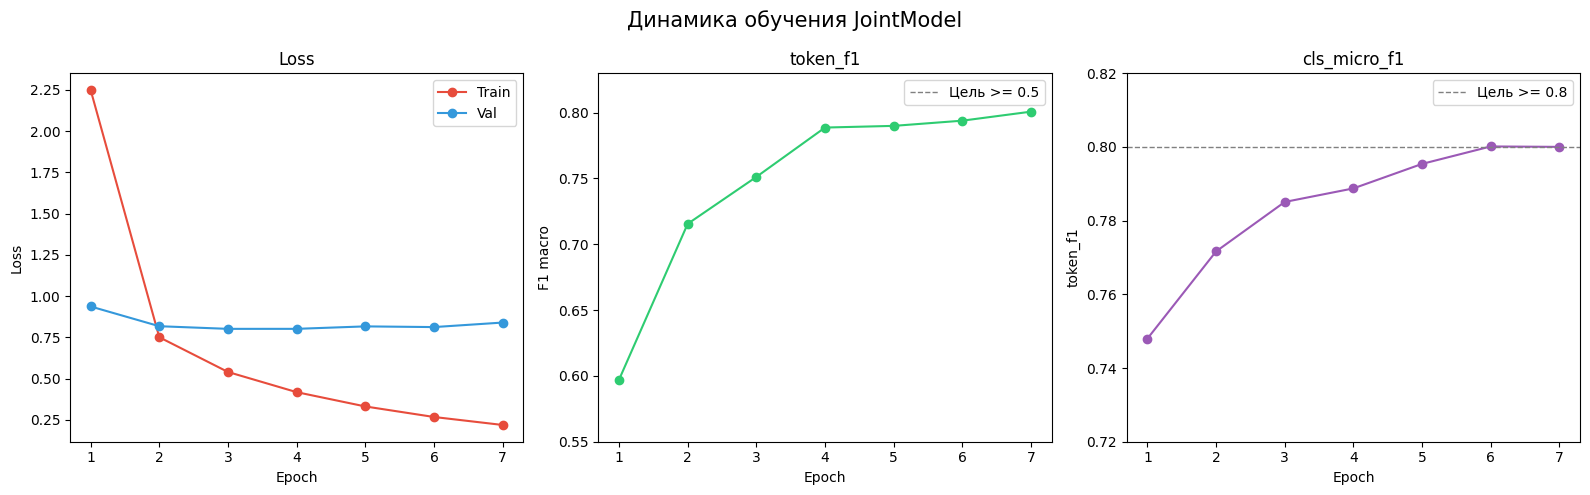

 Epoch   train_loss   val_loss   token_f1   cls_micro_f1
     1       2.2500     0.9371     0.5971         0.7480
     2       0.7506     0.8175     0.7155         0.7716
     3       0.5400     0.8014     0.7512         0.7851
     4       0.4177     0.8015     0.7887         0.7887
     5       0.3310     0.8164     0.7900         0.7954
     6       0.2672     0.8122     0.7939         0.8001
     7       0.2188     0.8396     0.8008         0.8000


In [32]:
epochs = history["epoch"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Динамика обучения JointModel", fontsize=15)

# Loss
axes[0].plot(epochs, history["train_loss"], "o-", label="Train", color="#e74c3c")
axes[0].plot(epochs, history["val_loss"],   "o-", label="Val",   color="#3498db")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# token_f1
axes[1].plot(epochs, history["token_f1"], "o-", color="#2ecc71")
axes[1].axhline(0.5, ls="--", color="grey", linewidth=1, label="Цель >= 0.5")

# Эпоха лучшая
best_ep = best_metrics["epoch"]
best_tf1 = best_metrics["token_f1"]
axes[1].set_title("token_f1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 macro")
axes[1].set_ylim(0.55, 0.83)
axes[1].legend()
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# cls_micro_f1
axes[2].plot(epochs, history["cls_micro_f1"], "o-", color="#9b59b6")
axes[2].axhline(0.8, ls="--", color="grey", linewidth=1, label="Цель >= 0.8")


best_cmf1 = best_metrics["cls_micro_f1"]
axes[2].set_title("cls_micro_f1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("token_f1")
axes[2].set_ylim(0.72, 0.82)
axes[2].legend()
axes[2].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# Дополнительно сводную добавим
print(f"{'Epoch':>6} {'train_loss':>12} {'val_loss':>10} {'token_f1':>10} {'cls_micro_f1':>14}")
for i in range(len(epochs)):
    print(f"{history['epoch'][i]:>6} "
          f"{history['train_loss'][i]:>12.4f} "
          f"{history['val_loss'][i]:>10.4f} "
          f"{history['token_f1'][i]:>10.4f} "
          f"{history['cls_micro_f1'][i]:>14.4f}")

Что у нас выходит исходя из нашего обучения:
-  Если смотрим на train - то после первой эпохи идет резко вниз, затем снижение стабилизируется и становится более плавны, а для val стабилизируется примерно после 3-4 эпох, и модель перестает существенно улучшать результаты на валидационной выборке.
- Касательно разрыва между train и val, то он можно сказать указывает на небольшое переобучение, но при нашем стопе в обучении мы не довели до крайностей сильных.
- Что касается метрик, то token_f1 - на валидационной выборке растёт с увеличением числа эпох, а cls_micro_f1 - на второй эпохе дает значительный прирост, а потом улучшения снижаются, и метрика движется практически в одном диапазоне.

Можно сказать, что модель эффективно учится различать классы, метрики стабильно растут и достигают заданного уровня. Исходя из того, что у нас изначально классы не особо балансно были разделены и данных не могу сказать, что много было - поэтому у нас обучение тяжело идет на возрастание после достижения уровня 0.79.

Не могу сказать, что дело в выборе модели, так как в работе были испытаны помимо используемой модели следующие:
1. DeepPavlov/rubert-base-cased
2. sberbank-ai/ruBert-base
3. ai-forever/ruBert-base
4. sberbank-ai/ruElectra-small
5. sberbank-ai/ruElectra-base
6. cointegrated/rubert-tiny2
7. sergeyzh/rubert-tiny-turbo
8. deepvk/deberta-v1-base

В качестве рекомендаций - можно рассмотреть дальнейшее обучение (больше эпох) или тонкую настройку гиперпараметров для незначительного улучшения метрик. Также стоит пересмотреть на предмет возможных ошибок на валидационной выборке для выявления слабых мест модели.

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, #aeca10 30%, #ffffff 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 7. Финальный эксперимент на тестовый выборке</strong>
</div>

In [33]:
# Загружаем лучшую модель
model.load_state_dict(torch.load("model/best_joint_model.pt", map_location=DEVICE))

print(f"Эпоха: {best_metrics['epoch']}")
print(f"token_f1: {best_metrics['token_f1']:.4f}")
print(f"cls_micro_f1: {best_metrics['cls_micro_f1']:.4f}")

# Быстрая оценка с порогом 0.5 для ориентира
test_loss, test_token_f1, test_cls_micro_f1 = evaluate(model, test_loader)
print(f"\ntoken_f1={test_token_f1:.4f} | cls_micro_f1={test_cls_micro_f1:.4f}")

Эпоха: 7
token_f1: 0.8008
cls_micro_f1: 0.8000


C:\Users\xndrf\AppData\Local\Temp\ipykernel_23840\1143446574.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model/best_joint_model.pt"


token_f1=0.8089 | cls_micro_f1=0.8104


В нашем случае когда данные несбалансированы, модель занижает уверенность по редким классам, и мы выполним сдвиг порога, который сможет позволить найти баланс, для предупреждения переобучения. Будем подбирать порог на val, а не на test - чтобы не подглядывать в тестовые данные

In [34]:
# Подбор оптимального порога на val, оценка на test
model.eval()
all_probs_val, all_trues_val = [], []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        all_probs_val.append(torch.sigmoid(out["cls_logits"]).cpu().numpy())
        all_trues_val.append(batch["event_labels"].cpu().numpy().astype(int))

all_probs_val = np.vstack(all_probs_val)
all_trues_val = np.vstack(all_trues_val)

best_thresh, best_f1 = 0.5, 0.0
print("Подбор порога на val:")
for thresh in np.arange(0.20, 0.81, 0.05):
    preds = (all_probs_val > thresh).astype(int)
    f1 = f1_score(all_trues_val, preds, average="micro", zero_division=0)
    print(f"  threshold={thresh:.2f} - cls_micro_f1={f1:.4f}")
    if f1 > best_f1:
        best_f1, best_thresh = f1, float(thresh)

print(f"\nЛучший порог: {best_thresh:.2f} - val cls_micro_f1={best_f1:.4f}")

# Финальная оценка на test с оптимальным порогом
test_loss, test_token_f1, test_cls_micro_f1 = evaluate(model, test_loader, threshold=best_thresh)

print(f"Финальный результат (threshold={best_thresh:.2f}):")
print(f"Test loss: {test_loss:.4f}")
print(f"token_f1 : {test_token_f1:.4f}")   
print(f"cls_micro_f1: {test_cls_micro_f1:.4f}")

Подбор порога на val:
  threshold=0.20 - cls_micro_f1=0.7668
  threshold=0.25 - cls_micro_f1=0.7821
  threshold=0.30 - cls_micro_f1=0.7940
  threshold=0.35 - cls_micro_f1=0.7972
  threshold=0.40 - cls_micro_f1=0.7959
  threshold=0.45 - cls_micro_f1=0.7994
  threshold=0.50 - cls_micro_f1=0.8000
  threshold=0.55 - cls_micro_f1=0.7962
  threshold=0.60 - cls_micro_f1=0.7954
  threshold=0.65 - cls_micro_f1=0.7958
  threshold=0.70 - cls_micro_f1=0.7882
  threshold=0.75 - cls_micro_f1=0.7834
  threshold=0.80 - cls_micro_f1=0.7688

Лучший порог: 0.50 - val cls_micro_f1=0.8000
Финальный результат (threshold=0.50):
Test loss: 0.7736
token_f1 : 0.8089
cls_micro_f1: 0.8104


Исходя из того, что threshold=0.50 - можно сказать, что модель хорошо откалибрована, и её вероятность близка к реальным частотам классов. Также мы достигли требуемых метрик в поставленной задаче.
Изначальная задача можно сказать достигнута и модель решает сразу две задачи не жертвуя качеством ни на одной метрике.

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, #aeca10 30%, #ffffff 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 8. Инференс и анализ ошибок</strong>
</div>

In [ ]:
def predict(text: str, threshold: float = None):
    
    """Инференс на произвольном тексте: возвращает NER-метки и вероятности характеристик

    Args:
        text (str): входной текст
        threshold (float, optional): порог для классификации. Defaults to None.

    Returns:
        tuple: кортеж из NER-меток и вероятностей характеристик
    """    

    if threshold is None:
        threshold = best_thresh  # используем порог, найденный на val

    model.eval()
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LEN,
        return_offsets_mapping=True,
    )
    offset_mapping = enc.pop("offset_mapping")[0].numpy()
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        out = model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])

    # NER
    token_ids = enc["input_ids"][0].cpu().numpy()
    token_preds = out["token_logits"][0].argmax(-1).cpu().numpy()
    tokens_str = tokenizer.convert_ids_to_tokens(token_ids)

    ner_results = []
    for tok, pred, (start, end) in zip(tokens_str, token_preds, offset_mapping):
        if tok in (tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token):
            continue
        if tok.startswith("##") or start == end:
            continue
        ner_results.append((text[start:end], id2tag[pred]))

    # CLS
    probs = torch.sigmoid(out["cls_logits"][0]).cpu().numpy()
    cls_results = list(zip(CLS_LABELS, probs.tolist()))

    return ner_results, cls_results

In [36]:
# Тестовый пример
test_text = "Иван Иванов, сотрудник Газпрома, полетел в Париж 15 мая 2023 года."
ner_res, cls_res = predict(test_text)

# CLS:
print("CLS probabilities:")
for label, prob in cls_res:
    print(f"{label}: {prob:.4f}")

print()

# NER:
print("Token predictions:")
for word, tag in ner_res:
    print(f"{word}: {tag}")

CLS probabilities:
WORKPLACE: 0.9864
ALTERNATIVE_NAME: 0.9649
WORKS_AS: 0.9906
PARTICIPANT_IN: 0.9055
POINT_IN_TIME: 0.9394
TAKES_PLACE_IN: 0.8035
HEADQUARTERED_IN: 0.2980
ORIGINS_FROM: 0.2167
LOCATED_IN: 0.5713
AGENT: 0.5286
AGE_IS: 0.6813
HAS_CAUSE: 0.1154
PRODUCES: 0.0060
AWARDED_WITH: 0.0423
PART_OF: 0.1782
IDEOLOGY_OF: 0.0114
MEMBER_OF: 0.0376
CONVICTED_OF: 0.0323
INANIMATE_INVOLVED: 0.0912
SUBEVENT_OF: 0.0053
SUBORDINATE_OF: 0.6982
KNOWS: 0.1987
MEDICAL_CONDITION: 0.0177
PARENT_OF: 0.1123
PLACE_RESIDES_IN: 0.0755
OWNER_OF: 0.2211
ABBREVIATION: 0.2340
FOUNDED_BY: 0.1218
ORGANIZES: 0.0401
PENALIZED_AS: 0.0336

Token predictions:
Иван: B-PERSON
Иванов: I-PERSON
,: O
сотрудник: B-PROFESSION
Газпром: I-PROFESSION
,: O
полет: B-EVENT
в: O
Париж: B-CITY
15: B-DATE
мая: I-DATE
2023: I-DATE
года: I-DATE
.: O


В целом предсказания выглядят логичными и интерпретируемыми. Модель понимает контекст, видит персону, работадателя, действия дату. Есть небольшие ошибки в NER на границах цепочек и спорные CLS характеристики, но возможно это нюанс данного датасета

Выполним анализ ошибок на примерах из test

In [37]:
model.eval()
n_analyzed = 0

for batch in test_loader:
    batch_gpu = {k: v.to(DEVICE) for k, v in batch.items()}
    with torch.no_grad():
        out = model(
            input_ids = batch_gpu["input_ids"],
            attention_mask = batch_gpu["attention_mask"],
        )

    # Анализируем по 2 примера из каждого батча
    for i in range(min(len(batch_gpu["input_ids"]), 2)):
        tokens_i = tokenizer.convert_ids_to_tokens(batch_gpu["input_ids"][i].cpu())
        true_ner = batch_gpu["labels"][i].cpu().numpy()
        pred_ner = out["token_logits"][i].argmax(-1).cpu().numpy()

        print(f"\nПример {n_analyzed + 1}:")
        print(f"{'Токен':<20} {'Истина':<15} {'Предсказание':<15} ОШИБКА")
        print(f"{'─'*60}")

        errors = 0
        for tok, true, pred in zip(tokens_i, true_ner, pred_ner):
            if true == -100:
                continue  # пропускаем субтокены и спецтокены
            true_str = id2tag[true]
            pred_str = id2tag[pred]
            ok = " " if true == pred else "ОШИБКА"
            if true != pred:
                errors += 1
            print(f"  {tok:<20} {true_str:<15} {pred_str:<15} {ok}")

        print(f"Итого ошибок NER: {errors}")
        n_analyzed += 1

    if n_analyzed >= 5:
        break



Пример 1:
Токен                Истина          Предсказание    ОШИБКА
────────────────────────────────────────────────────────────
  Пост                 B-PROFESSION    B-PROFESSION     
  России               I-PROFESSION    I-PROFESSION     
  при                  I-PROFESSION    I-PROFESSION     
  ООН                  I-PROFESSION    I-PROFESSION     
  назначен             B-EVENT         B-EVENT          
  Василий              B-PERSON        B-PERSON         
  Не                   I-PERSON        I-PERSON         
  Василий              B-PERSON        B-PERSON         
  Не                   I-PERSON        I-PERSON         
  Президент            B-PROFESSION    B-PROFESSION     
  России               I-PROFESSION    I-PROFESSION     
  Владимир             B-PERSON        B-PERSON         
  Путин                I-PERSON        I-PERSON         
  на                   B-EVENT         B-EVENT          
  заместителя          B-PROFESSION    B-PROFESSION     
  министра   

Можно сказать, что большинство ошибок сосредоточены на трех сценариях:

- длинные составные сущности
- семантически неоднозначные токены
- редкие типы сущностей

Всё это возможное поведение модели обученной на маленьком датасете - ключевые сущности (PERSON, ORGANIZATION, DATE, CITY).

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgb(108, 233, 36) 0%, #aeca10 30%, #ffffff 60%, rgb(255, 255, 255) 100%); border-left: 4px solid #ffffff; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(71, 255, 237, 0.6), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">БЛОК 9. Итоги работы</strong>
</div>

**В работе использован публичный датасет NEREL:**

- 58 уникальных NER-меток
- 30 бинарных характеристик
- Выполнена разбивка датасета на обучение 60/20/20
- Выполнена фильтрация текстов длиннее 350 слов
Основной проблемой данных являлся дисбаланс классов, который не давал сделать более высокие метрики

**Касательно архитектуры модели - JoinModel:**

- Базовая модель: surdan/LaBSE_ner_nerel - по сути она предобученная была на NEREL
- NER-голова - 58 классов
- CLS-голова - 30 классов
- Автобаланс лосов 
- гипперпараметры LR=2e-5, DROPOUT=0.3, batch=8. И взято 10 эпох с остановкой.

**Финальные метрики на тесте достигнуты при threshold=0.50:**
- token_f1 > 0.50
- cls_micro_f1 > 0.80

**Основные ошибки:**
- Длинные составные сущности
- Семантические неоднозначные токены
- Редкие типы сущностей

В целом гипотеза подтверждена  и совместное обучение позволило нам добиться желаемых результатов.
Что касается потенциала для улучшения то можно предложить - увеличить количество эпох и добрать ещё данных.